# PTEN dihedrals: decision trees, random forest, and averaging

This notebook focuses on **decision-tree** interpretation, **random forest** classification with leave-one-variant-out CV, **nested** feature-selection workflows, and **arithmetic vs circular** averaging of backbone dihedrals.

**Data:** place `pten.csv` in the same directory (and optionally `unknown.csv` for external predictions).

**Dependencies:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `scikit-learn`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.tree import DecisionTreeClassifier, plot_tree


In [2]:
DATA_PATH = Path("pten.csv")

df = pd.read_csv(DATA_PATH)
effect = {"no effect": 0, "loss of function": 1}
df["type"] = [effect[item] for item in df["type"]]

group = df.groupby(["group"])
pten = group.mean()
pten


,type,psi1,phi2,psi2,phi3,psi3,phi4,psi4,phi5,psi5,...,psi398,phi399,psi399,phi400,psi400,phi401,psi401,phi402,psi402,phi403
group,,,,,,,,,,,,,,,,,,,,,
A126D,1.0,118.785275,-93.444738,121.894545,-79.625665,78.253051,-81.738532,85.560279,-86.667738,125.463822,...,113.416739,-75.495838,77.094000,-85.621792,114.577245,-89.983839,134.276498,-89.937219,87.088459,-84.516242
A126G,1.0,85.567259,-95.845849,102.449607,-83.201851,93.643503,-86.206869,75.903783,-86.738073,118.607341,...,125.559948,-94.241635,47.872398,-81.890375,132.780781,-85.200908,132.414977,-54.035733,67.645467,-86.836184
A126P,0.0,119.683064,-88.475182,105.718806,-71.474250,87.381182,-83.142787,126.438022,-79.903576,114.672212,...,109.639456,-90.498592,69.851760,-72.674861,115.866184,-64.176716,92.248772,-88.914307,83.491105,-84.587484
A126S,0.0,86.534313,-82.489624,86.551125,-85.067064,75.725284,-74.280049,93.437003,-83.705233,105.060459,...,133.223428,-86.165096,105.138933,-81.914162,114.490236,-78.219273,108.786245,-80.452637,92.392370,-85.435775
A126V,0.0,87.961110,-85.611942,116.959234,-74.199287,120.598179,-81.482147,132.641942,-77.780881,119.759051,...,124.248930,-76.818725,101.378338,-75.443075,102.874996,-81.679379,108.978851,-79.140827,101.009254,-84.776299
C136F,1.0,88.911648,-88.221158,71.991122,-81.024572,96.961569,-76.711911,122.293723,-71.070245,136.608718,...,101.338306,-87.463430,80.159264,-84.259768,87.837811,-92.594064,128.125766,-81.797081,110.090163,-86.825763
D162H,0.0,79.779491,-79.639838,115.579620,-79.874571,97.152515,-86.876083,118.610115,-82.110137,116.944184,...,112.915732,-91.332057,92.818562,-85.456432,129.015477,-74.660270,130.311984,-86.766471,102.587740,-85.144610
D268E,0.0,99.349506,-89.549377,131.344835,-86.764819,118.922612,-78.995738,131.239135,-81.860476,117.587573,...,131.216162,-85.844007,90.428082,-78.140712,119.196817,-73.345661,134.782911,-90.806532,50.524736,-87.397037
E73K,1.0,77.708813,-58.842023,121.754784,-60.692598,71.693499,-83.212113,93.943935,-50.861723,116.179907,...,97.076161,-87.185527,100.619591,-83.073453,115.252748,-82.797113,137.884138,-74.230779,87.445425,-86.195610


## Decision trees (full model and stepwise ablations)


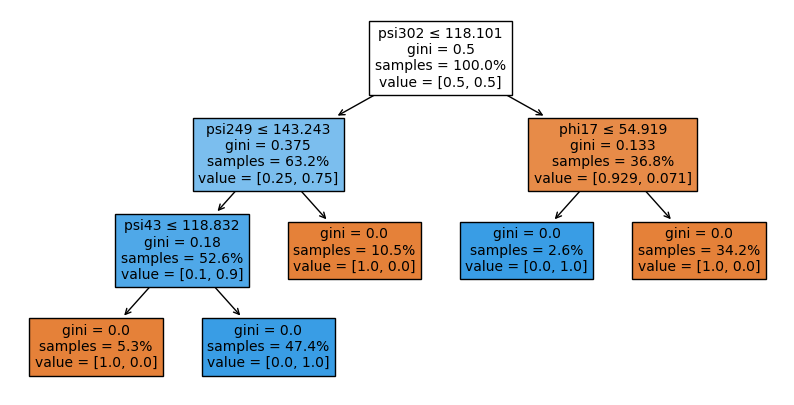

In [3]:
tree = DecisionTreeClassifier(random_state=34)
tree.fit(pten.drop("type", axis=1), pten["type"])
plt.figure(figsize=(10, 5))
plot_tree(
    tree,
    filled=True,
    fontsize=10,
    feature_names=pten.columns.drop("type"),
    proportion=True,
)
for text in plt.gcf().findobj(match=plt.Text):
    if "<=" in text.get_text():
        text.set_text(text.get_text().replace("<=", "≤"))
plt.show()


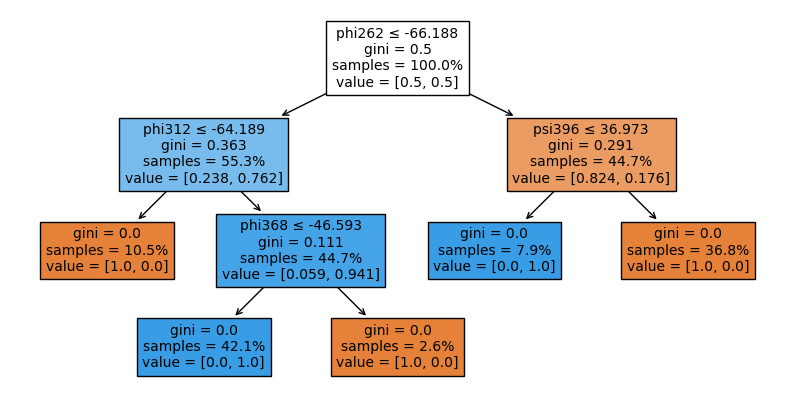

In [4]:
pten_1 = pten.drop(["psi302", "psi249", "phi17", "psi43"], axis=1)
tree = DecisionTreeClassifier(random_state=34)
tree.fit(pten_1.drop("type", axis=1), pten_1["type"])
plt.figure(figsize=(10, 5))
plot_tree(
    tree,
    filled=True,
    fontsize=10,
    feature_names=pten_1.columns.drop("type"),
    proportion=True,
)
for text in plt.gcf().findobj(match=plt.Text):
    if "<=" in text.get_text():
        text.set_text(text.get_text().replace("<=", "≤"))
plt.show()


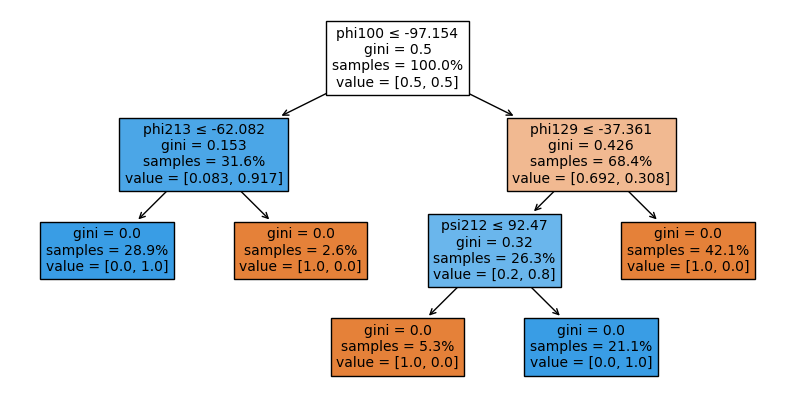

In [5]:
pten_2 = pten_1.drop(["phi262", "phi312", "psi396", "phi368"], axis=1)
tree = DecisionTreeClassifier(random_state=34)
tree.fit(pten_2.drop("type", axis=1), pten_2["type"])
plt.figure(figsize=(10, 5))
plot_tree(
    tree,
    filled=True,
    fontsize=10,
    feature_names=pten_2.columns.drop("type"),
    proportion=True,
)
for text in plt.gcf().findobj(match=plt.Text):
    if "<=" in text.get_text():
        text.set_text(text.get_text().replace("<=", "≤"))
plt.show()


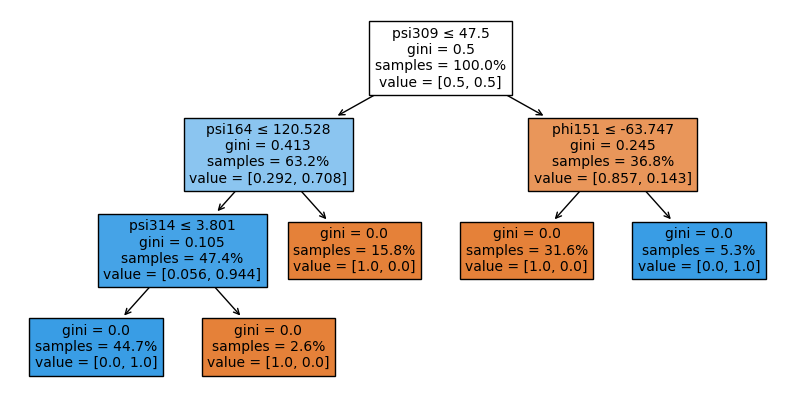

In [6]:
pten_3 = pten_2.drop(["phi100", "phi213", "phi129", "psi212"], axis=1)
tree = DecisionTreeClassifier(random_state=34)
tree.fit(pten_3.drop("type", axis=1), pten_3["type"])
plt.figure(figsize=(10, 5))
plot_tree(
    tree,
    filled=True,
    fontsize=10,
    feature_names=pten_3.columns.drop("type"),
    proportion=True,
)
for text in plt.gcf().findobj(match=plt.Text):
    if "<=" in text.get_text():
        text.set_text(text.get_text().replace("<=", "≤"))
plt.show()


## Random forest: leave-one-variant-out cross-validation (12 DT-selected dihedrals)


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import matthews_corrcoef
import pandas as pd
#ml model 123 dt
ml = pd.concat([pten['type'], pten['psi302'], pten['psi249'], pten['phi17'], pten['psi43'], pten['phi262'], pten['phi312'], pten['psi396'], pten['phi368'], pten['phi100'], pten['phi213'], pten['phi129'], pten['psi212']], axis=1)
acc=0
grouping = ['A126D', 'A126P', 'A126S', 'A126V', 'C136F', 'D162H', 'D268E', 'E73K', 'F271S', 'F341V', 'G129D', 'G165E', 'I135K',
            'I135T', 'K128R', 'K402N', 'L181P', 'L345Q', 'M198I', 'M198R', 'N262S', 'N276S', 'N340H', 'N356D', 'N356H', 'P354Q',
            'R130A', 'R130G', 'R130L', 'R130M', 'S229T', 'T348I', 'T78A', 'V217D', 'V343E', 'WT', 'Y180H', 'A126G']
sc = StandardScaler()
y_true_all = []
y_pred_all = []
for group in grouping:
  X_pre_train = ml.loc[ml.index != group]
  X_pre_test = ml.loc[ml.index == group]
  X_train =  sc.fit_transform(X_pre_train.iloc[:, 1:])
  X_test = sc.transform(X_pre_test.iloc[:,1:])
  y_train = X_pre_train['type']
  y_test = X_pre_test['type']

  clf=RandomForestClassifier(n_estimators=5000)
  clf.fit(X_train, y_train)
  y_preds = clf.predict(X_test)
  proba = clf.predict_proba(X_test)[0][1]  # P(y=1|X)

  #print(group, clf.score(X_train, y_train), clf.score(X_test, y_test))

  acc += clf.score(X_test, y_test)
  y_true_all.append(y_test.values[0])
  y_pred_all.append(y_preds[0])
 # print(confusion_matrix(y_test, y_preds,  labels = [0, 1, 2]))
  print(f"{group}: predicted={y_preds[0]}, true={y_test.values[0]}, prob={proba:.3f}")
  print('-----------------------------------')

print('Accuracy is:', acc/38)
print("Confusion Matrix:")
print(confusion_matrix(y_true_all, y_pred_all))

print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_all, target_names=["no effect", "loss of function"]))

print("\nAccuracy:", sum([t==p for t, p in zip(y_true_all, y_pred_all)]) / len(y_true_all))

mcc = matthews_corrcoef(y_true_all, y_pred_all)
print("MCC:", mcc)


A126D: predicted=1.0, true=1.0, prob=0.615
-----------------------------------
A126P: predicted=0.0, true=0.0, prob=0.185
-----------------------------------
A126S: predicted=0.0, true=0.0, prob=0.369
-----------------------------------
A126V: predicted=0.0, true=0.0, prob=0.226
-----------------------------------
C136F: predicted=1.0, true=1.0, prob=0.929
-----------------------------------
D162H: predicted=0.0, true=0.0, prob=0.187
-----------------------------------
D268E: predicted=0.0, true=0.0, prob=0.351
-----------------------------------
E73K: predicted=1.0, true=1.0, prob=0.628
-----------------------------------
F271S: predicted=1.0, true=1.0, prob=0.699
-----------------------------------
F341V: predicted=1.0, true=1.0, prob=0.674
-----------------------------------
G129D: predicted=1.0, true=1.0, prob=0.733
-----------------------------------
G165E: predicted=1.0, true=1.0, prob=0.598
-----------------------------------
I135K: predicted=1.0, true=1.0, prob=0.634
----------

### Nearest centroid (Euclidean): fine K, arithmetic mean — no leakage

Leave-one-variant-out: each fold ranks features by **class centroid separation** on training variants only, keeps top **K** dihedrals, then classifies the held-out variant by nearest centroid in that K-dimensional space. Uses `pten` from above (`group.mean()` = arithmetic mean per variant).

In [19]:
from collections import Counter
import numpy as np
import pandas as pd
from scipy.spatial.distance import euclidean
from sklearn.metrics import accuracy_score, matthews_corrcoef

pten_simple = pten.drop(columns=["type"])
type_map = pten["type"].astype(int)

grouping = [
    "A126D", "A126P", "A126S", "A126V", "C136F", "D162H", "D268E", "E73K", "F271S", "F341V",
    "G129D", "G165E", "I135K", "I135T", "K128R", "K402N", "L181P", "L345Q", "M198I", "M198R",
    "N262S", "N276S", "N340H", "N356D", "N356H", "P354Q", "R130A", "R130G", "R130L", "R130M",
    "S229T", "T348I", "T78A", "V217D", "V343E", "WT", "Y180H", "A126G",
]

K_fine = [31]

print("=" * 70)
print("Fine K Sweep: Euclidean + Arithmetic Mean (PTEN, No Leakage)")
print("=" * 70)

best_acc = 0.0
best_mcc = -1.0
best_k = 0
best_fold_feats = {}
best_true = []
best_pred = []

for K in K_fine:
    all_true, all_pred = [], []
    fold_feats = {}

    for group in grouping:
        X_train = pten_simple.loc[pten_simple.index != group]
        X_test = pten_simple.loc[pten_simple.index == group]
        y_train = type_map.loc[X_train.index]

        c0 = X_train[y_train == 0].mean()
        c1 = X_train[y_train == 1].mean()
        feat_sep = (c0 - c1).abs().sort_values(ascending=False)

        top_k = feat_sep.head(K).index.tolist()
        fold_feats[group] = top_k

        centroid_0 = c0[top_k].values
        centroid_1 = c1[top_k].values
        test_point = X_test[top_k].values[0]

        d0 = euclidean(test_point, centroid_0)
        d1 = euclidean(test_point, centroid_1)

        pred = 0 if d0 < d1 else 1
        all_true.append(int(type_map.loc[group]))
        all_pred.append(pred)

    acc = accuracy_score(all_true, all_pred)
    mcc = matthews_corrcoef(all_true, all_pred)

    details = ""
    for i, group in enumerate(grouping):
        if all_pred[i] != all_true[i]:
            details += f" {group}=WRONG"
    if not details:
        details = " all correct"

    print(f"  K={K:2d}: Acc={acc:.3f} ({int(acc*len(grouping))}/{len(grouping)}), MCC={mcc:+.3f} |{details}")

    if acc > best_acc or (acc == best_acc and mcc > best_mcc):
        best_acc = acc
        best_mcc = mcc
        best_k = K
        best_fold_feats = fold_feats.copy()
        best_true = all_true[:]
        best_pred = all_pred[:]

print(f"\n{'=' * 70}")
print(f"Best: Euclidean + Arithmetic Mean, K={best_k}")
print(f"Accuracy: {best_acc:.3f} ({int(best_acc*len(grouping))}/{len(grouping)})")
print(f"MCC: {best_mcc:+.3f}")
print(f"{'=' * 70}")

print(f"\nFeatures selected per fold (K={best_k}):")
for group in grouping:
    feats = best_fold_feats[group]
    print(f"  {group}: {feats}")

all_sel = [f for feats in best_fold_feats.values() for f in feats]
feat_counts = Counter(all_sel)
print(f"\nFeature frequency at K={best_k}:")
for f, c in feat_counts.most_common():
    print(f"  {f}: {c}/{len(grouping)} folds ({c/len(grouping)*100:.0f}%)")

Fine K Sweep: Euclidean + Arithmetic Mean (PTEN, No Leakage)
  K=31: Acc=0.737 (28/38), MCC=+0.476 | A126D=WRONG G165E=WRONG M198I=WRONG M198R=WRONG N356D=WRONG P354Q=WRONG R130G=WRONG R130L=WRONG S229T=WRONG V343E=WRONG

Best: Euclidean + Arithmetic Mean, K=31
Accuracy: 0.737 (28/38)
MCC: +0.476

Features selected per fold (K=31):
  A126D: ['psi128', 'psi306', 'psi209', 'psi350', 'phi352', 'phi7', 'psi124', 'phi129', 'psi396', 'phi282', 'psi399', 'phi207', 'psi352', 'psi210', 'psi383', 'psi281', 'psi302', 'phi293', 'phi160', 'phi328', 'psi309', 'psi388', 'psi2', 'psi229', 'phi10', 'phi364', 'psi7', 'psi297', 'psi300', 'psi362', 'psi308']
  A126P: ['psi128', 'psi209', 'psi350', 'psi306', 'phi7', 'psi396', 'psi399', 'phi352', 'phi129', 'phi293', 'psi352', 'psi302', 'psi210', 'phi282', 'psi383', 'psi281', 'phi364', 'psi229', 'psi7', 'psi2', 'psi309', 'phi207', 'phi160', 'psi300', 'phi328', 'phi10', 'psi382', 'psi291', 'psi124', 'psi308', 'psi297']
  A126S: ['psi128', 'psi306', 'psi350', 

### Nested LOOCV with multi-round DT feature selection


Nested LOOCV on PTEN averaged data (K=12)
Number of variants: 38
  A126D: pred=1.0, true=1.0, prob(LoF)=0.586 [OK]
  A126P: pred=0.0, true=0.0, prob(LoF)=0.374 [OK]
  A126S: pred=0.0, true=0.0, prob(LoF)=0.476 [OK]
  A126V: pred=0.0, true=0.0, prob(LoF)=0.431 [OK]
  C136F: pred=1.0, true=1.0, prob(LoF)=0.588 [OK]
  D162H: pred=0.0, true=0.0, prob(LoF)=0.444 [OK]
  D268E: pred=0.0, true=0.0, prob(LoF)=0.391 [OK]
  E73K: pred=1.0, true=1.0, prob(LoF)=0.594 [OK]
  F271S: pred=0.0, true=1.0, prob(LoF)=0.460 [WRONG]
  F341V: pred=0.0, true=1.0, prob(LoF)=0.479 [WRONG]
  G129D: pred=0.0, true=1.0, prob(LoF)=0.340 [WRONG]
  G165E: pred=0.0, true=1.0, prob(LoF)=0.292 [WRONG]
  I135K: pred=1.0, true=1.0, prob(LoF)=0.541 [OK]
  I135T: pred=1.0, true=0.0, prob(LoF)=0.534 [WRONG]
  K128R: pred=1.0, true=0.0, prob(LoF)=0.656 [WRONG]
  K402N: pred=0.0, true=0.0, prob(LoF)=0.458 [OK]
  L181P: pred=0.0, true=1.0, prob(LoF)=0.368 [WRONG]
  L345Q: pred=1.0, true=1.0, prob(LoF)=0.551 [OK]
  M198I: pred=1

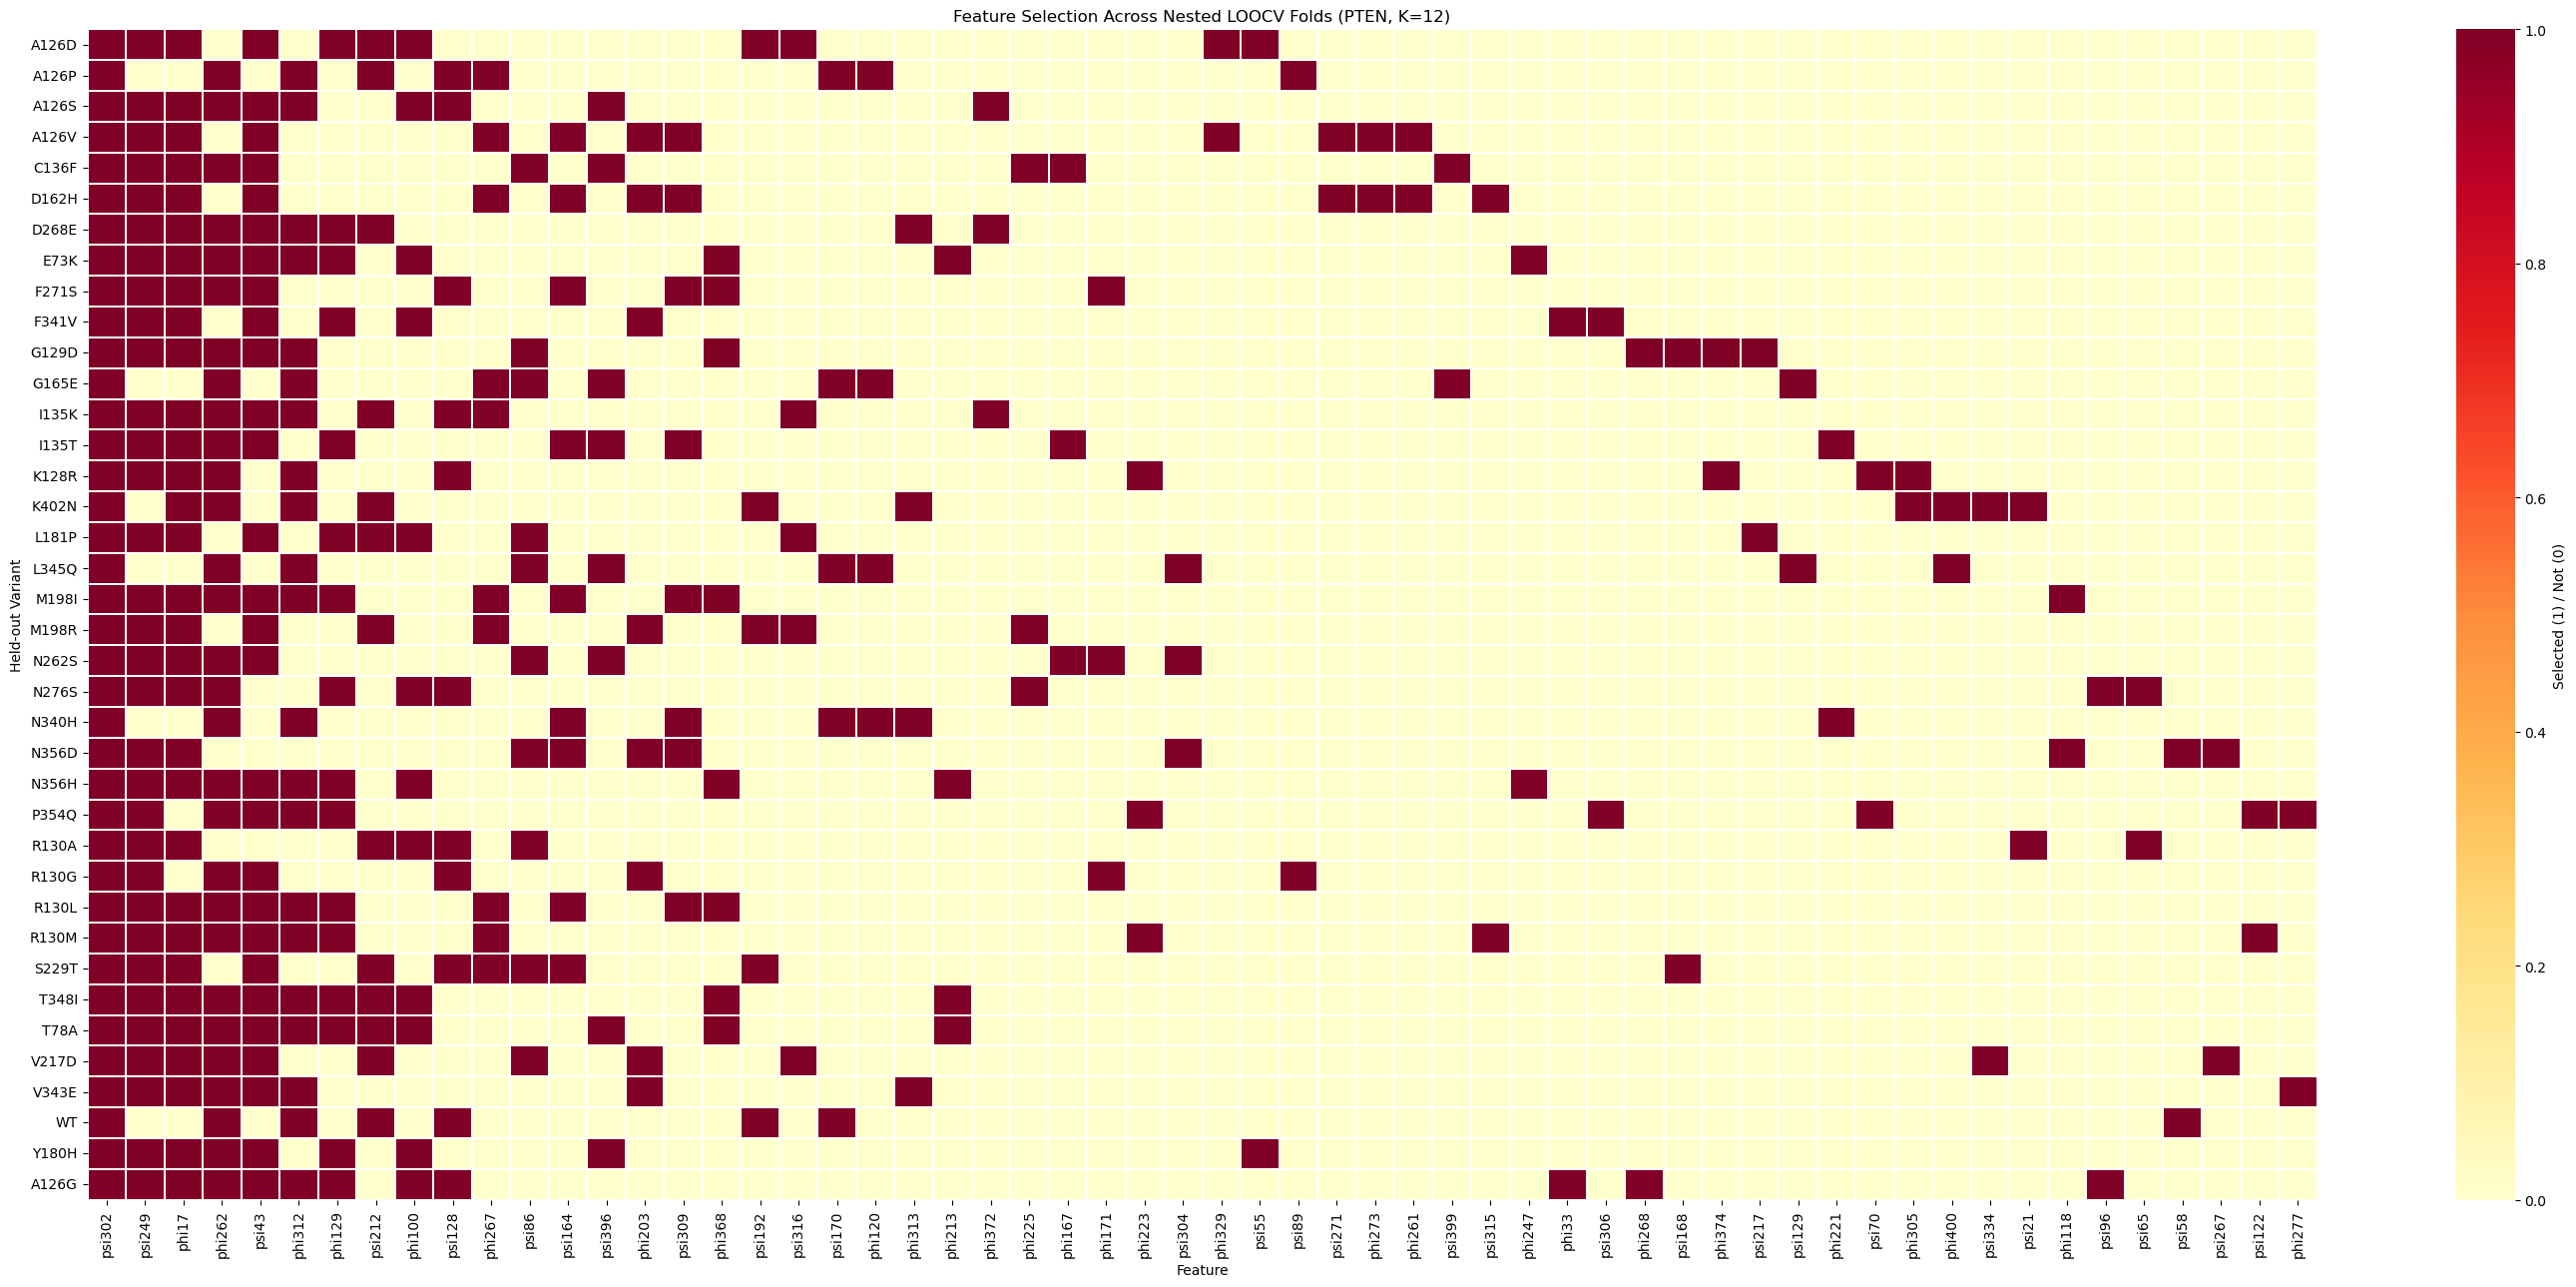


Per-fold overlap with original 12 features:
  Mean: 6.3/12
  Min:  3/12
  Max:  12/12


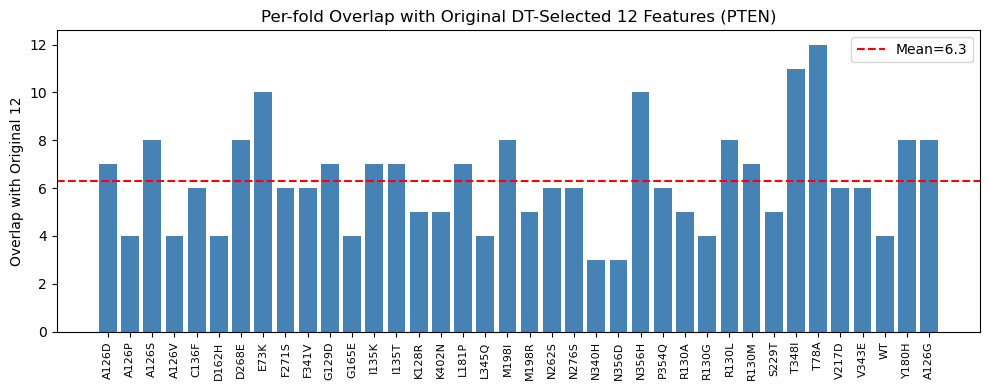

In [9]:
import builtins
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    matthews_corrcoef, accuracy_score
)
from collections import Counter

original_12 = ['psi302', 'psi249', 'phi17', 'psi43', 'phi262', 'phi312',
               'psi396', 'phi368', 'phi100', 'phi213', 'phi129', 'psi212']

grouping = ['A126D', 'A126P', 'A126S', 'A126V', 'C136F', 'D162H', 'D268E',
            'E73K', 'F271S', 'F341V', 'G129D', 'G165E', 'I135K', 'I135T',
            'K128R', 'K402N', 'L181P', 'L345Q', 'M198I', 'M198R', 'N262S',
            'N276S', 'N340H', 'N356D', 'N356H', 'P354Q', 'R130A', 'R130G',
            'R130L', 'R130M', 'S229T', 'T348I', 'T78A', 'V217D', 'V343E',
            'WT', 'Y180H', 'A126G']

def multi_round_dt_select(X_train, y_train, target_k=12, max_rounds=20, random_state=34):
    selected = []
    remaining = X_train.columns.tolist()
    for r in range(max_rounds):
        if len(selected) >= target_k or len(remaining) == 0:
            break
        dt = DecisionTreeClassifier(random_state=random_state)
        dt.fit(X_train[remaining], y_train)
        imp = pd.Series(dt.feature_importances_, index=remaining)
        used = imp[imp > 0].sort_values(ascending=False).index.tolist()
        if len(used) == 0:
            break
        selected.extend(used)
        remaining = [c for c in remaining if c not in used]
    return selected[:target_k]

# --- Nested LOOCV ---
X_full = pten.drop('type', axis=1)
y_full = pten['type']
TARGET_K = 12

all_true, all_pred, all_proba = [], [], []
fold_features = {}

print("=" * 60)
print(f"Nested LOOCV on PTEN averaged data (K={TARGET_K})")
print(f"Number of variants: {len(grouping)}")
print("=" * 60)

for group in grouping:
    X_train = X_full.loc[X_full.index != group]
    X_test  = X_full.loc[X_full.index == group]
    y_train = y_full.loc[y_full.index != group]
    y_test  = y_full.loc[y_full.index == group]

    top_features = multi_round_dt_select(X_train, y_train, target_k=TARGET_K)
    fold_features[group] = top_features

    sc = StandardScaler()
    X_tr = sc.fit_transform(X_train[top_features])
    X_te = sc.transform(X_test[top_features])

    clf = RandomForestClassifier(n_estimators=5000, random_state=42)
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)
    proba = clf.predict_proba(X_te)[0][1]

    all_true.append(y_test.values[0])
    all_pred.append(y_pred[0])
    all_proba.append(proba)

    status = "OK" if y_pred[0] == y_test.values[0] else "WRONG"
    print(f"  {group}: pred={y_pred[0]}, true={y_test.values[0]}, "
          f"prob(LoF)={proba:.3f} [{status}]")

acc = accuracy_score(all_true, all_pred)
mcc = matthews_corrcoef(all_true, all_pred)
print(f"\nAccuracy: {acc:.3f} ({int(acc*len(grouping))}/{len(grouping)})")
print(f"MCC: {mcc:.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(all_true, all_pred))
print("\nClassification Report:")
print(classification_report(all_true, all_pred,
                            target_names=["No Effect", "Loss of Function"]))

# --- Feature overlap analysis ---
print("\n" + "=" * 60)
print("Feature Overlap Analysis")
print("=" * 60)

print(f"\nOriginal DT-selected 12: {original_12}\n")

all_selected = [f for feats in fold_features.values() for f in feats]
feature_counts = Counter(all_selected)

print("Original feature recovery rate:")
for feat in original_12:
    count = len([1 for feats in fold_features.values() if feat in feats])
    print(f"  {feat}: selected in {count}/{len(grouping)} folds ({count/len(grouping)*100:.0f}%)")

# Features selected in ALL folds
universal = [f for f, c in feature_counts.items() if c == len(grouping)]
print(f"\nFeatures in ALL {len(grouping)} folds: {universal if universal else 'None'}")

# Features in >=75% of folds
stable = [(f, c) for f, c in feature_counts.most_common()
          if c >= len(grouping) * 0.75]
print(f"\nFeatures in >=75% of folds:")
for f, c in stable:
    in_orig = "(in original 12)" if f in original_12 else "(NEW)"
    print(f"  {f}: {c}/{len(grouping)} folds ({c/len(grouping)*100:.0f}%) {in_orig}")

# --- Heatmap (only features appearing in >=2 folds) ---
freq_features = [f for f, c in feature_counts.most_common() if c >= 2]
freq_features.sort(key=lambda f: -feature_counts[f])

heatmap_data = pd.DataFrame(0, index=grouping, columns=freq_features)
for group, feats in fold_features.items():
    for f in feats:
        if f in freq_features:
            heatmap_data.loc[group, f] = 1

fig_width = builtins.max(14, int(len(freq_features) * 0.5))
fig_height = builtins.max(8, int(len(grouping) * 0.35))
plt.figure(figsize=(fig_width, fig_height))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.3, annot=False,
            cbar_kws={"label": "Selected (1) / Not (0)"})
plt.title(f"Feature Selection Across Nested LOOCV Folds (PTEN, K={TARGET_K})")
plt.xlabel("Feature")
plt.ylabel("Held-out Variant")
plt.tight_layout()
plt.show()

# --- Comparison: per-fold overlap with original ---
overlaps = []
for group in grouping:
    ov = len(set(fold_features[group]) & set(original_12))
    overlaps.append(ov)

print(f"\nPer-fold overlap with original 12 features:")
print(f"  Mean: {np.mean(overlaps):.1f}/12")
print(f"  Min:  {np.min(overlaps)}/12")
print(f"  Max:  {np.max(overlaps)}/12")

plt.figure(figsize=(10, 4))
plt.bar(range(len(grouping)), overlaps, color='steelblue')
plt.xticks(range(len(grouping)), grouping, rotation=90, fontsize=8)
plt.ylabel("Overlap with Original 12")
plt.title("Per-fold Overlap with Original DT-Selected 12 Features (PTEN)")
plt.axhline(y=np.mean(overlaps), color='red', linestyle='--',
            label=f'Mean={np.mean(overlaps):.1f}')
plt.legend()
plt.tight_layout()
plt.show()


### RF feature importance vs DT-selected 12; LOOCV with fixed feature sets


Test 1: RF Feature Importance Ranking (PTEN)

RF Top-12 features: ['psi302', 'phi262', 'phi100', 'psi212', 'psi86', 'psi396', 'phi129', 'psi209', 'phi223', 'phi203', 'phi225', 'psi271']
DT-selected 12:     ['psi302', 'psi249', 'phi17', 'psi43', 'phi262', 'phi312', 'psi396', 'phi368', 'phi100', 'phi213', 'phi129', 'psi212']

Overlap: 6/12 features
Common features: {'phi262', 'psi212', 'psi396', 'psi302', 'phi129', 'phi100'}


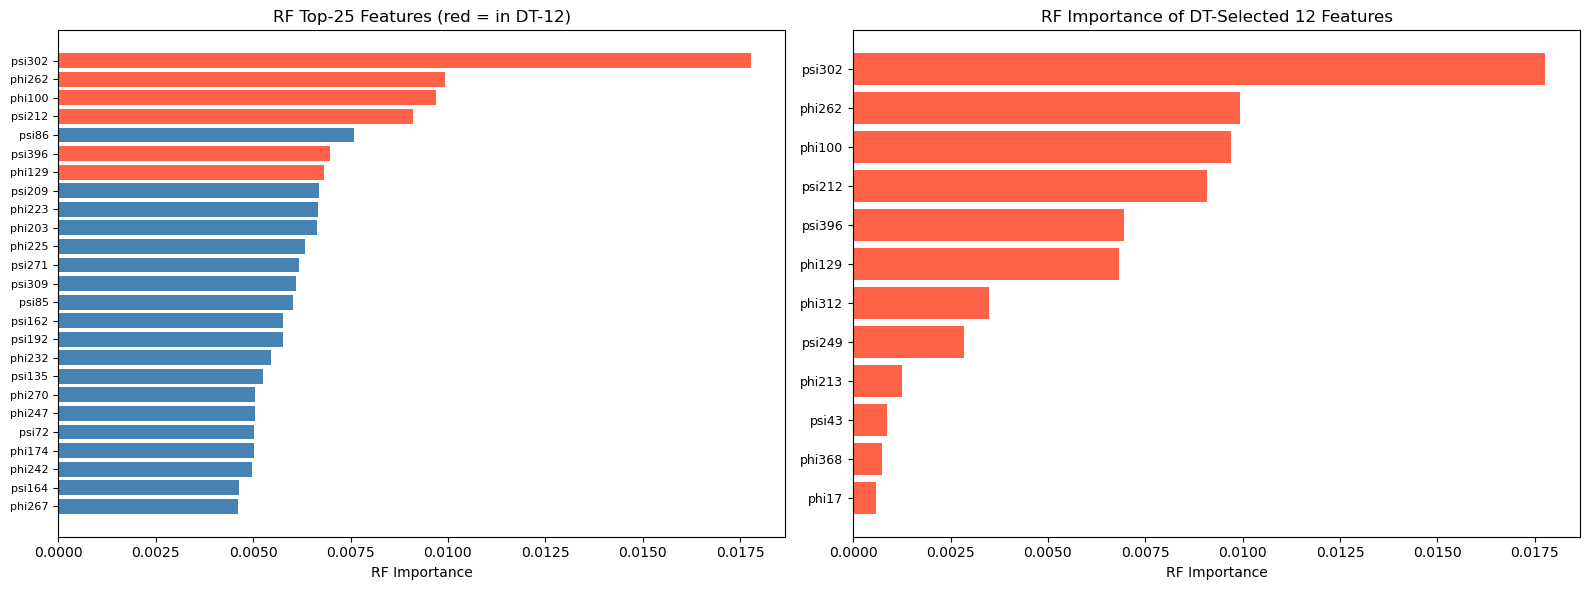


LOOCV Comparison: DT-12 vs RF Top-12 features (PTEN)

  DT-selected 12:
    Accuracy = 0.947 (36/38)
    MCC      = 0.895

  RF top-12:
    Accuracy = 0.868 (33/38)
    MCC      = 0.738


In [10]:
# --- Test 1: RF feature importance on full averaged data ---
rf_full = RandomForestClassifier(n_estimators=5000, random_state=42)
rf_full.fit(X_full, y_full)

rf_imp = pd.Series(rf_full.feature_importances_, index=X_full.columns)
rf_top12 = rf_imp.sort_values(ascending=False).head(12).index.tolist()

overlap_rf_dt = set(rf_top12) & set(original_12)

print("=" * 60)
print("Test 1: RF Feature Importance Ranking (PTEN)")
print("=" * 60)
print(f"\nRF Top-12 features: {rf_top12}")
print(f"DT-selected 12:     {original_12}")
print(f"\nOverlap: {len(overlap_rf_dt)}/12 features")
print(f"Common features: {overlap_rf_dt if overlap_rf_dt else 'None'}")

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_imp_sorted = rf_imp.sort_values(ascending=False).head(25)
colors = ['tomato' if f in original_12 else 'steelblue' for f in rf_imp_sorted.index]
axes[0].barh(range(len(rf_imp_sorted)), rf_imp_sorted.values, color=colors)
axes[0].set_yticks(range(len(rf_imp_sorted)))
axes[0].set_yticklabels(rf_imp_sorted.index, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel("RF Importance")
axes[0].set_title("RF Top-25 Features (red = in DT-12)")

dt_in_rf = rf_imp[original_12].sort_values(ascending=False)
axes[1].barh(range(len(dt_in_rf)), dt_in_rf.values, color='tomato')
axes[1].set_yticks(range(len(dt_in_rf)))
axes[1].set_yticklabels(dt_in_rf.index, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel("RF Importance")
axes[1].set_title("RF Importance of DT-Selected 12 Features")

plt.tight_layout()
plt.show()

# --- LOOCV comparison: DT-12 vs RF top-12 ---
print("\n" + "=" * 60)
print("LOOCV Comparison: DT-12 vs RF Top-12 features (PTEN)")
print("=" * 60)

for label, features in [("DT-selected 12", original_12),
                         ("RF top-12", rf_top12)]:
    preds, trues = [], []
    for group in grouping:
        X_tr = X_full.loc[X_full.index != group, features]
        X_te = X_full.loc[X_full.index == group, features]
        y_tr = y_full.loc[y_full.index != group]
        y_te = y_full.loc[y_full.index == group]

        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)

        clf = RandomForestClassifier(n_estimators=5000, random_state=42)
        clf.fit(X_tr_s, y_tr)
        preds.append(clf.predict(X_te_s)[0])
        trues.append(y_te.values[0])

    a = accuracy_score(trues, preds)
    m = matthews_corrcoef(trues, preds)
    print(f"\n  {label}:")
    print(f"    Accuracy = {a:.3f} ({int(a*len(grouping))}/{len(grouping)})")
    print(f"    MCC      = {m:.3f}")


### Nested LOOCV with RF-based inner feature selection


In [11]:
# --- Nested LOOCV with RF-based feature selection ---
all_true_rf, all_pred_rf = [], []
fold_features_rf = {}

print("=" * 60)
print(f"Nested LOOCV with RF Feature Selection (PTEN, K={TARGET_K})")
print("=" * 60)

for group in grouping:
    X_train = X_full.loc[X_full.index != group]
    X_test  = X_full.loc[X_full.index == group]
    y_train = y_full.loc[y_full.index != group]
    y_test  = y_full.loc[y_full.index == group]

    rf_inner = RandomForestClassifier(n_estimators=5000, random_state=42)
    rf_inner.fit(X_train, y_train)
    imp = pd.Series(rf_inner.feature_importances_, index=X_train.columns)
    top_k = imp.sort_values(ascending=False).head(TARGET_K).index.tolist()
    fold_features_rf[group] = top_k

    sc = StandardScaler()
    X_tr = sc.fit_transform(X_train[top_k])
    X_te = sc.transform(X_test[top_k])

    clf = RandomForestClassifier(n_estimators=5000, random_state=42)
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)

    all_true_rf.append(y_test.values[0])
    all_pred_rf.append(y_pred[0])

    status = "OK" if y_pred[0] == y_test.values[0] else "WRONG"
    print(f"  {group}: pred={y_pred[0]}, true={y_test.values[0]} [{status}]")

acc_rf = accuracy_score(all_true_rf, all_pred_rf)
mcc_rf = matthews_corrcoef(all_true_rf, all_pred_rf)
print(f"\nAccuracy: {acc_rf:.3f} ({int(acc_rf*len(grouping))}/{len(grouping)})")
print(f"MCC: {mcc_rf:.3f}")

# --- Feature stability ---
all_sel_rf = [f for feats in fold_features_rf.values() for f in feats]
feat_counts_rf = Counter(all_sel_rf)

print("\n--- RF-based Feature Stability ---")
print(f"\nOriginal DT-12 feature recovery in RF-selected folds:")
for feat in original_12:
    count = len([1 for feats in fold_features_rf.values() if feat in feats])
    print(f"  {feat}: {count}/{len(grouping)} folds ({count/len(grouping)*100:.0f}%)")

stable_rf = [(f, c) for f, c in feat_counts_rf.most_common()
             if c >= len(grouping) * 0.75]
print(f"\nRF features in >=75% of folds:")
for f, c in stable_rf:
    in_orig = "(in DT-12)" if f in original_12 else "(NEW)"
    print(f"  {f}: {c}/{len(grouping)} folds ({c/len(grouping)*100:.0f}%) {in_orig}")

# --- Overlap between DT nested and RF nested ---
print("\n--- Overlap: DT Nested vs RF Nested ---")
for group in grouping:
    dt_set = set(fold_features[group])
    rf_set = set(fold_features_rf[group])
    ov = len(dt_set & rf_set)
    if ov > 0:
        print(f"  {group}: {ov}/12 overlap ({dt_set & rf_set})")

# Per-fold overlap
ov_list = [len(set(fold_features[g]) & set(fold_features_rf[g])) for g in grouping]
print(f"\nMean overlap (DT nested vs RF nested): {np.mean(ov_list):.1f}/12")

# --- Summary comparison ---
print("\n" + "=" * 60)
print("Summary: PTEN Nested LOOCV Comparison")
print("=" * 60)
print(f"  DT nested LOOCV:  Acc={accuracy_score(all_true, all_pred):.3f}, "
      f"MCC={matthews_corrcoef(all_true, all_pred):.3f}")
print(f"  RF nested LOOCV:  Acc={acc_rf:.3f}, MCC={mcc_rf:.3f}")


Nested LOOCV with RF Feature Selection (PTEN, K=12)
  A126D: pred=0.0, true=1.0 [WRONG]
  A126P: pred=1.0, true=0.0 [WRONG]
  A126S: pred=0.0, true=0.0 [OK]
  A126V: pred=1.0, true=0.0 [WRONG]
  C136F: pred=1.0, true=1.0 [OK]
  D162H: pred=0.0, true=0.0 [OK]
  D268E: pred=0.0, true=0.0 [OK]
  E73K: pred=0.0, true=1.0 [WRONG]
  F271S: pred=1.0, true=1.0 [OK]
  F341V: pred=0.0, true=1.0 [WRONG]
  G129D: pred=0.0, true=1.0 [WRONG]
  G165E: pred=1.0, true=1.0 [OK]
  I135K: pred=1.0, true=1.0 [OK]
  I135T: pred=1.0, true=0.0 [WRONG]
  K128R: pred=1.0, true=0.0 [WRONG]
  K402N: pred=1.0, true=0.0 [WRONG]
  L181P: pred=0.0, true=1.0 [WRONG]
  L345Q: pred=1.0, true=1.0 [OK]
  M198I: pred=1.0, true=0.0 [WRONG]
  M198R: pred=0.0, true=1.0 [WRONG]
  N262S: pred=1.0, true=0.0 [WRONG]
  N276S: pred=0.0, true=1.0 [WRONG]
  N340H: pred=1.0, true=0.0 [WRONG]
  N356D: pred=1.0, true=0.0 [WRONG]
  N356H: pred=1.0, true=0.0 [WRONG]
  P354Q: pred=1.0, true=0.0 [WRONG]
  R130A: pred=0.0, true=1.0 [WRONG]
 

### K sweep: nested LOOCV accuracy and overlap vs number of features K


K Sweep: Nested LOOCV with DT Feature Selection (PTEN, 804 total features)
  K= 12: Acc=0.553, MCC=+0.105, Overlap w/ orig-12=6.3/12, Pairwise overlap=0.39
  K= 16: Acc=0.605, MCC=+0.211, Overlap w/ orig-12=7.5/12, Pairwise overlap=0.39
  K= 20: Acc=0.579, MCC=+0.159, Overlap w/ orig-12=8.2/12, Pairwise overlap=0.41
  K= 24: Acc=0.579, MCC=+0.159, Overlap w/ orig-12=8.6/12, Pairwise overlap=0.42
  K= 32: Acc=0.632, MCC=+0.263, Overlap w/ orig-12=8.8/12, Pairwise overlap=0.42


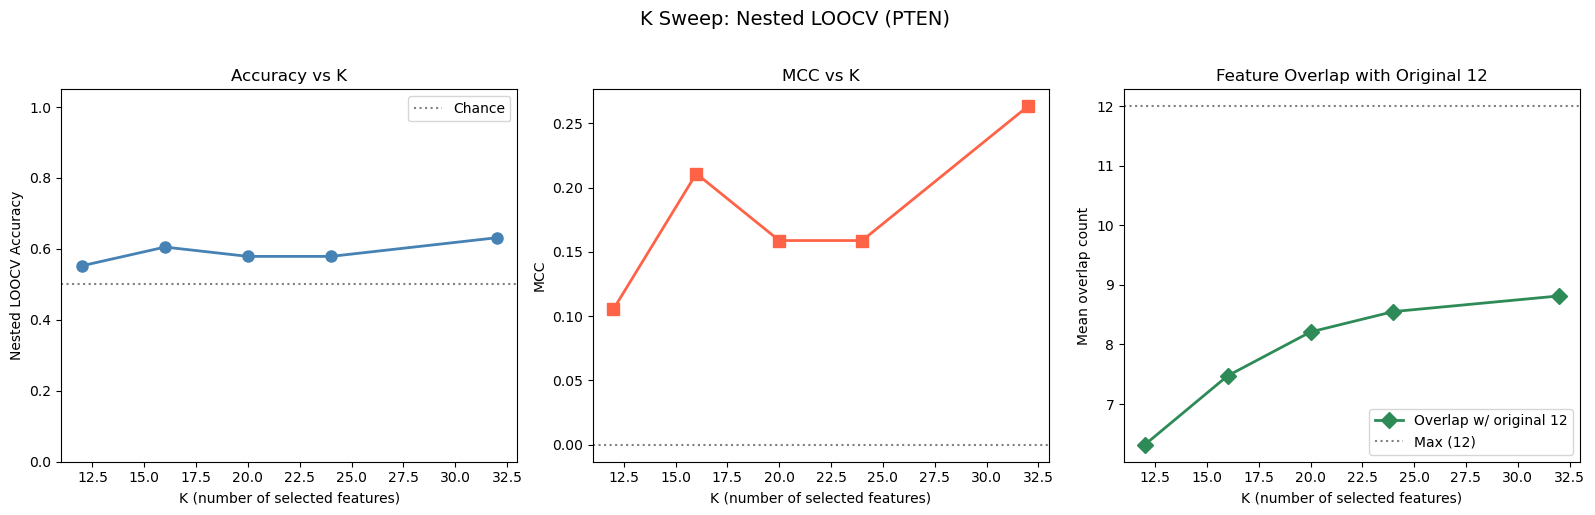


Full results table:
 K      acc      mcc  mean_overlap_orig12  mean_pairwise_jaccard  actual_k
12 0.552632 0.105409             6.315789               0.392366      12.0
16 0.605263 0.210819             7.473684               0.394559      16.0
20 0.578947 0.158777             8.210526               0.411309      20.0
24 0.578947 0.158777             8.552632               0.421171      24.0
32 0.631579 0.263158             8.815789               0.424831      32.0


In [12]:
import builtins
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, matthews_corrcoef
from collections import Counter

original_12 = ['psi302', 'psi249', 'phi17', 'psi43', 'phi262', 'phi312',
               'psi396', 'phi368', 'phi100', 'phi213', 'phi129', 'psi212']

grouping = ['A126D', 'A126P', 'A126S', 'A126V', 'C136F', 'D162H', 'D268E',
            'E73K', 'F271S', 'F341V', 'G129D', 'G165E', 'I135K', 'I135T',
            'K128R', 'K402N', 'L181P', 'L345Q', 'M198I', 'M198R', 'N262S',
            'N276S', 'N340H', 'N356D', 'N356H', 'P354Q', 'R130A', 'R130G',
            'R130L', 'R130M', 'S229T', 'T348I', 'T78A', 'V217D', 'V343E',
            'WT', 'Y180H', 'A126G']

def multi_round_dt_select(X_train, y_train, target_k=12, max_rounds=20, random_state=34):
    selected = []
    remaining = X_train.columns.tolist()
    for r in range(max_rounds):
        if len(selected) >= target_k or len(remaining) == 0:
            break
        dt = DecisionTreeClassifier(random_state=random_state)
        dt.fit(X_train[remaining], y_train)
        imp = pd.Series(dt.feature_importances_, index=remaining)
        used = imp[imp > 0].sort_values(ascending=False).index.tolist()
        if len(used) == 0:
            break
        selected.extend(used)
        remaining = [c for c in remaining if c not in used]
    return selected[:target_k]

X_full = pten.drop('type', axis=1)
y_full = pten['type']
n_folds = len(grouping)
n_features = len(X_full.columns)

K_values = [12, 16, 20, 24, 32]
results = []

print("=" * 70)
print(f"K Sweep: Nested LOOCV with DT Feature Selection (PTEN, {n_features} total features)")
print("=" * 70)

for K in K_values:
    all_true, all_pred = [], []
    fold_feats = {}

    for group in grouping:
        X_train = X_full.loc[X_full.index != group]
        X_test  = X_full.loc[X_full.index == group]
        y_train = y_full.loc[y_full.index != group]
        y_test  = y_full.loc[y_full.index == group]

        top_features = multi_round_dt_select(X_train, y_train, target_k=K)
        fold_feats[group] = top_features

        sc = StandardScaler()
        X_tr = sc.fit_transform(X_train[top_features])
        X_te = sc.transform(X_test[top_features])

        clf = RandomForestClassifier(n_estimators=5000, random_state=42)
        clf.fit(X_tr, y_train)
        y_pred = clf.predict(X_te)

        all_true.append(y_test.values[0])
        all_pred.append(y_pred[0])

    acc = accuracy_score(all_true, all_pred)
    mcc = matthews_corrcoef(all_true, all_pred)

    overlap_counts = []
    for g in grouping:
        ov = len(set(fold_feats[g]) & set(original_12))
        overlap_counts.append(ov)
    mean_overlap = np.mean(overlap_counts)

    pair_overlaps = []
    for i in range(n_folds):
        for j in range(i+1, n_folds):
            ov = len(set(fold_feats[grouping[i]]) & set(fold_feats[grouping[j]]))
            pair_overlaps.append(ov / K)
    mean_pair_overlap = np.mean(pair_overlaps)

    results.append({
        'K': K, 'acc': acc, 'mcc': mcc,
        'mean_overlap_orig12': mean_overlap,
        'mean_pairwise_jaccard': mean_pair_overlap,
        'actual_k': np.mean([len(fold_feats[g]) for g in grouping])
    })

    print(f"  K={K:3d}: Acc={acc:.3f}, MCC={mcc:+.3f}, "
          f"Overlap w/ orig-12={mean_overlap:.1f}/12, "
          f"Pairwise overlap={mean_pair_overlap:.2f}")

res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(res_df['K'], res_df['acc'], 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].axhline(y=0.5, color='gray', linestyle=':', label='Chance')
axes[0].set_xlabel('K (number of selected features)')
axes[0].set_ylabel('Nested LOOCV Accuracy')
axes[0].set_title('Accuracy vs K')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

axes[1].plot(res_df['K'], res_df['mcc'], 's-', color='tomato', linewidth=2, markersize=8)
axes[1].axhline(y=0, color='gray', linestyle=':')
axes[1].set_xlabel('K (number of selected features)')
axes[1].set_ylabel('MCC')
axes[1].set_title('MCC vs K')

axes[2].plot(res_df['K'], res_df['mean_overlap_orig12'], 'D-', color='seagreen',
             linewidth=2, markersize=8, label='Overlap w/ original 12')
axes[2].set_xlabel('K (number of selected features)')
axes[2].set_ylabel('Mean overlap count')
axes[2].set_title('Feature Overlap with Original 12')
axes[2].axhline(y=12, color='gray', linestyle=':', label='Max (12)')
axes[2].legend()

plt.suptitle('K Sweep: Nested LOOCV (PTEN)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nFull results table:")
print(res_df.to_string(index=False))


### Spearman correlation of feature-importance ranks across LOOCV folds


Computing full feature importance for each LOOCV fold...
  A126D done
  A126P done
  A126S done
  A126V done
  C136F done
  D162H done
  D268E done
  E73K done
  F271S done
  F341V done
  G129D done
  G165E done
  I135K done
  I135T done
  K128R done
  K402N done
  L181P done
  L345Q done
  M198I done
  M198R done
  N262S done
  N276S done
  N340H done
  N356D done
  N356H done
  P354Q done
  R130A done
  R130G done
  R130L done
  R130M done
  S229T done
  T348I done
  T78A done
  V217D done
  V343E done
  WT done
  Y180H done
  A126G done

Spearman Rank Correlation of Feature Importance Across Folds

  Random Forest:
    Mean Spearman ρ = 0.788 ± 0.034
    Range: [0.730, 0.897]


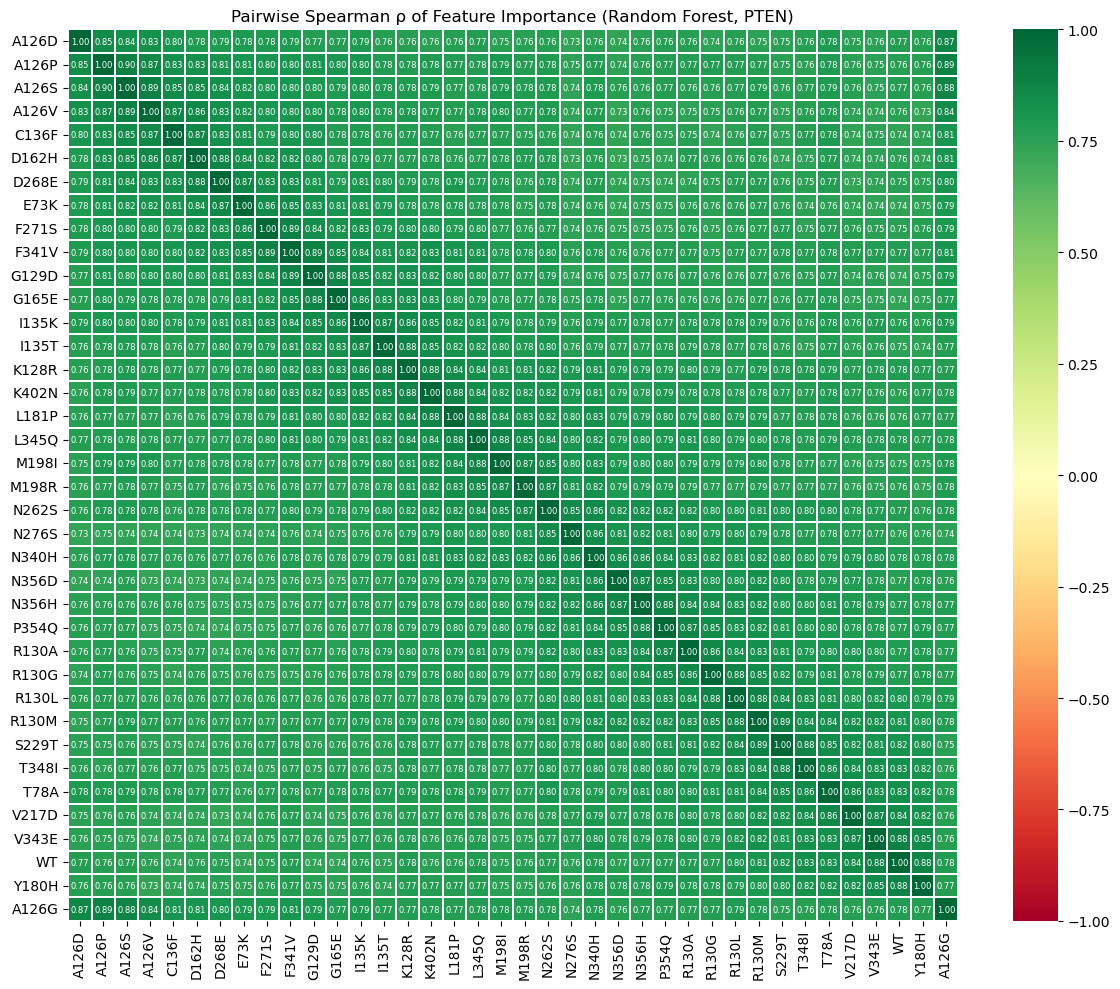


  Decision Tree:
    Mean Spearman ρ = 0.729 ± 0.314
    Range: [0.221, 1.000]


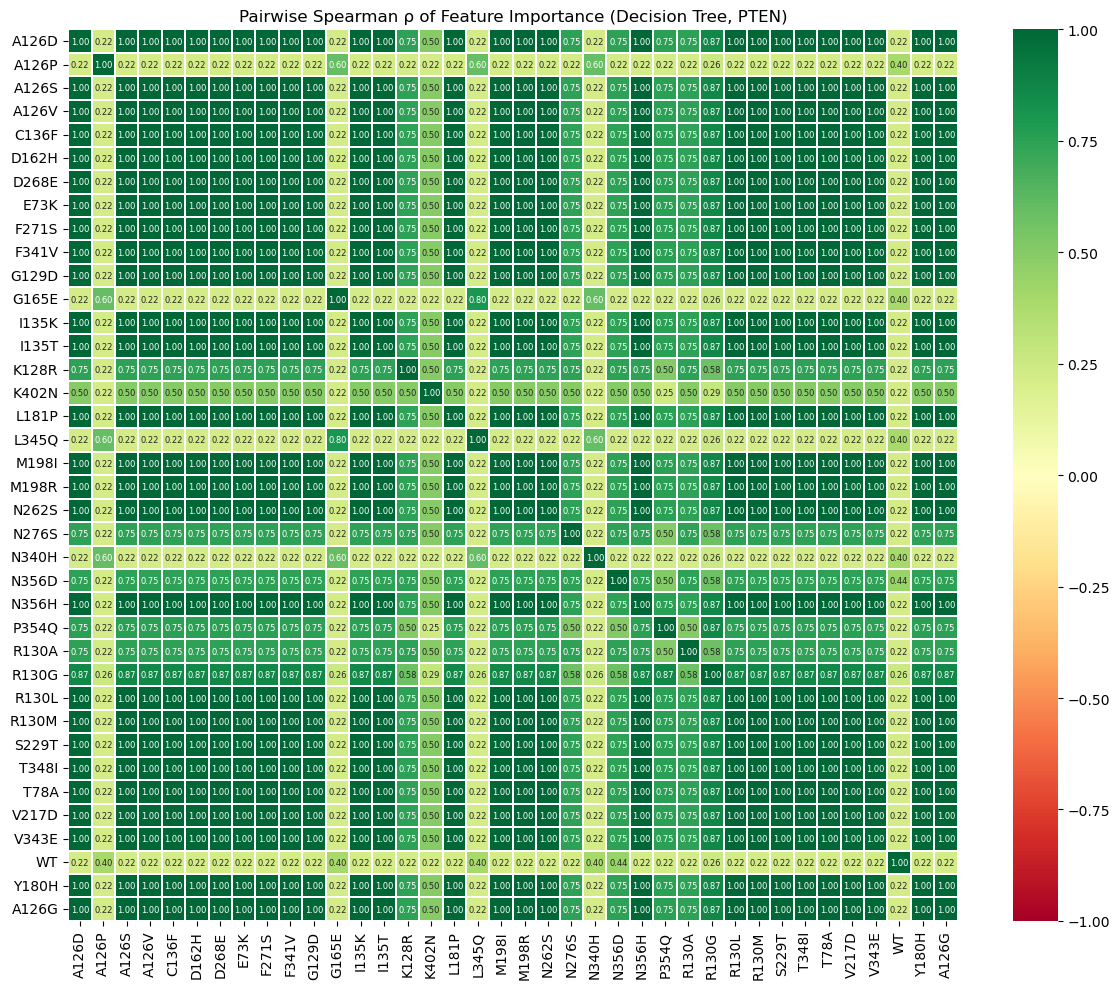


Rank of Original 12 DT-Selected Features in RF Importance (per fold)
       psi302  psi249  phi17  psi43  phi262  phi312  psi396  phi368  phi100  phi213  phi129  psi212
A126D     1.0    46.0  262.0  407.0     4.0    34.0    10.0   424.0     2.0   114.0    27.0     3.0
A126P     1.0    96.0  565.0  292.0     2.0    73.0    12.0   487.0     6.0   119.0    17.0     4.0
A126S     1.0    65.0  369.0  307.0     3.0    30.0    11.0   429.0     2.0   152.0    18.0     4.0
A126V     1.0    88.0  440.0  372.0     5.0    24.0    16.0   437.0     6.0   123.0     9.0     3.0
C136F     1.0    74.0  660.0  446.0     4.0    54.0    18.0   543.0     6.0   119.0     8.0     5.0
D162H     1.0    66.0  572.0  194.0     4.0    63.0    13.0   434.0     3.0   160.0    15.0     2.0
D268E     1.0    80.0  460.0  216.0     2.0    41.0    19.0   230.0     4.0   177.0    20.0     3.0
E73K      1.0    80.0  501.0  240.0     2.0    14.0    13.0   372.0     5.0   233.0    31.0     4.0
F271S     1.0   123.0  486.0  

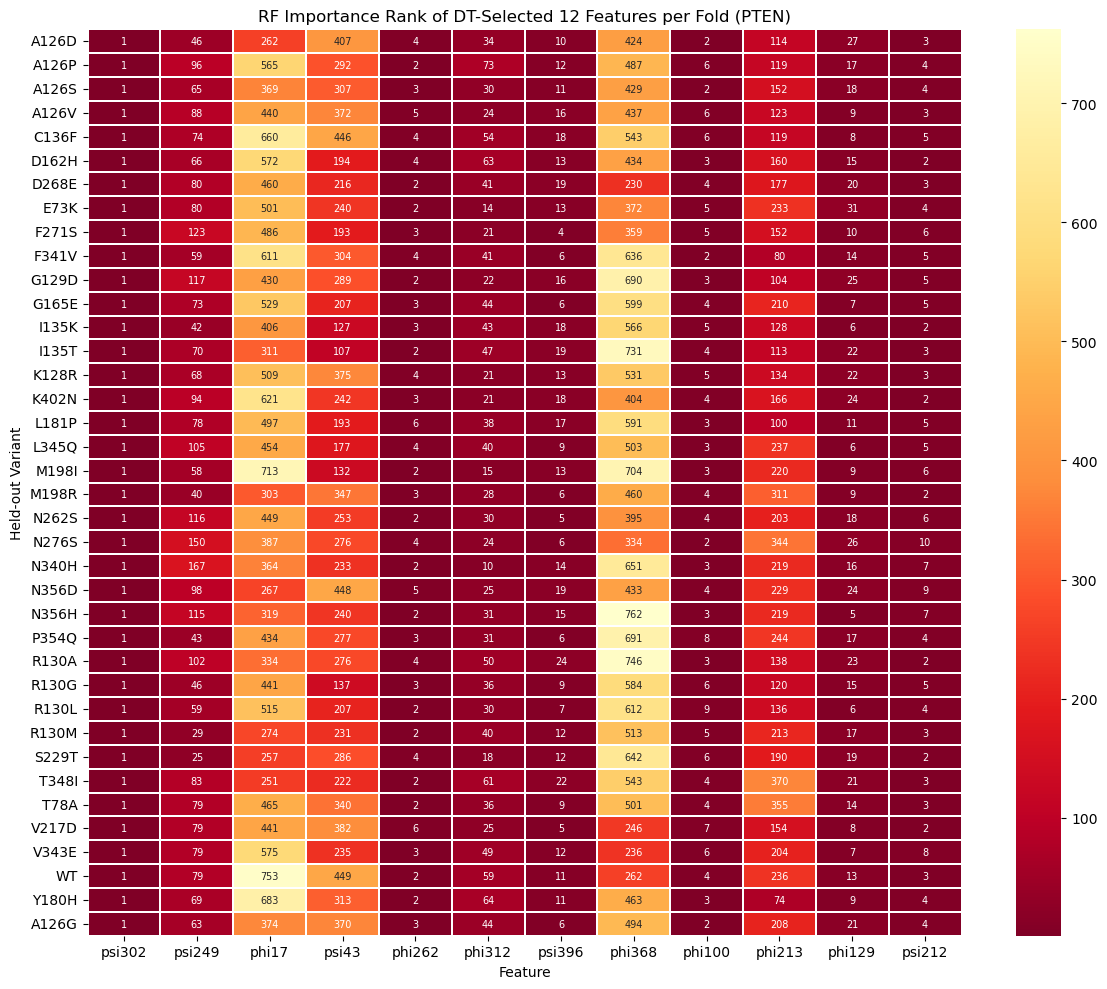


Global RF importance: rank of DT-selected 12 out of 804 features:
  psi302: rank 1/804 (top 0.1%, importance=0.0178)
  psi249: rank 62/804 (top 7.7%, importance=0.0029)
  phi17: rank 570/804 (top 70.9%, importance=0.0006)
  psi43: rank 384/804 (top 47.8%, importance=0.0009)
  phi262: rank 2/804 (top 0.2%, importance=0.0099)
  phi312: rank 49/804 (top 6.1%, importance=0.0035)
  psi396: rank 6/804 (top 0.7%, importance=0.0070)
  phi368: rank 457/804 (top 56.8%, importance=0.0007)
  phi100: rank 3/804 (top 0.4%, importance=0.0097)
  phi213: rank 227/804 (top 28.2%, importance=0.0012)
  phi129: rank 7/804 (top 0.9%, importance=0.0068)
  psi212: rank 4/804 (top 0.5%, importance=0.0091)


In [13]:
import builtins
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X_full = pten.drop('type', axis=1)
y_full = pten['type']
all_features = X_full.columns.tolist()
n_features = len(all_features)

grouping = ['A126D', 'A126P', 'A126S', 'A126V', 'C136F', 'D162H', 'D268E',
            'E73K', 'F271S', 'F341V', 'G129D', 'G165E', 'I135K', 'I135T',
            'K128R', 'K402N', 'L181P', 'L345Q', 'M198I', 'M198R', 'N262S',
            'N276S', 'N340H', 'N356D', 'N356H', 'P354Q', 'R130A', 'R130G',
            'R130L', 'R130M', 'S229T', 'T348I', 'T78A', 'V217D', 'V343E',
            'WT', 'Y180H', 'A126G']

original_12 = ['psi302', 'psi249', 'phi17', 'psi43', 'phi262', 'phi312',
               'psi396', 'phi368', 'phi100', 'phi213', 'phi129', 'psi212']

rf_importance_matrix = pd.DataFrame(index=grouping, columns=all_features, dtype=float)
dt_importance_matrix = pd.DataFrame(index=grouping, columns=all_features, dtype=float)

print("Computing full feature importance for each LOOCV fold...")
for group in grouping:
    X_train = X_full.loc[X_full.index != group]
    y_train = y_full.loc[y_full.index != group]

    rf = RandomForestClassifier(n_estimators=5000, random_state=42)
    rf.fit(X_train, y_train)
    rf_importance_matrix.loc[group] = rf.feature_importances_

    dt = DecisionTreeClassifier(random_state=34)
    dt.fit(X_train, y_train)
    dt_importance_matrix.loc[group] = dt.feature_importances_

    print(f"  {group} done")

# ---- Pairwise Spearman rank correlation ----
print("\n" + "=" * 60)
print("Spearman Rank Correlation of Feature Importance Across Folds")
print("=" * 60)

for label, imp_matrix in [("Random Forest", rf_importance_matrix),
                           ("Decision Tree", dt_importance_matrix)]:
    n = len(grouping)
    rho_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if i == j:
                rho_matrix[i, j] = 1.0
            else:
                rho, _ = spearmanr(imp_matrix.iloc[i], imp_matrix.iloc[j])
                rho_matrix[i, j] = rho

    upper_tri = rho_matrix[np.triu_indices(n, k=1)]
    mean_rho = np.mean(upper_tri)
    std_rho = np.std(upper_tri)
    min_rho = np.min(upper_tri)
    max_rho = np.max(upper_tri)

    print(f"\n  {label}:")
    print(f"    Mean Spearman ρ = {mean_rho:.3f} ± {std_rho:.3f}")
    print(f"    Range: [{min_rho:.3f}, {max_rho:.3f}]")

    plt.figure(figsize=(12, 10))
    sns.heatmap(pd.DataFrame(rho_matrix, index=grouping, columns=grouping),
                annot=True, fmt=".2f", cmap="RdYlGn", vmin=-1, vmax=1,
                linewidths=0.3, annot_kws={"size": 6})
    plt.title(f"Pairwise Spearman ρ of Feature Importance ({label}, PTEN)")
    plt.tight_layout()
    plt.show()

# ---- Rank of original 12 features in RF importance per fold ----
print("\n" + "=" * 60)
print("Rank of Original 12 DT-Selected Features in RF Importance (per fold)")
print("=" * 60)

rank_table = pd.DataFrame(index=grouping, columns=original_12, dtype=int)
for group in grouping:
    imp_sorted = rf_importance_matrix.loc[group].sort_values(ascending=False)
    ranks = {feat: list(imp_sorted.index).index(feat) + 1 for feat in original_12}
    rank_table.loc[group] = ranks

print(rank_table.to_string())
print(f"\nMean rank per feature (out of {n_features}):")
for feat in original_12:
    mean_rank = rank_table[feat].astype(float).mean()
    pct = mean_rank / n_features * 100
    print(f"  {feat}: mean rank = {mean_rank:.1f} / {n_features} (top {pct:.1f}%)")

plt.figure(figsize=(12, 10))
rank_table_float = rank_table.astype(float)
sns.heatmap(rank_table_float, annot=True, fmt=".0f", cmap="YlOrRd_r",
            linewidths=0.3, annot_kws={"size": 7})
plt.title("RF Importance Rank of DT-Selected 12 Features per Fold (PTEN)")
plt.xlabel("Feature")
plt.ylabel("Held-out Variant")
plt.tight_layout()
plt.show()

# ---- Global RF importance ----
rf_global = RandomForestClassifier(n_estimators=5000, random_state=42)
rf_global.fit(X_full, y_full)
global_imp = pd.Series(rf_global.feature_importances_, index=all_features).sort_values(ascending=False)

print(f"\nGlobal RF importance: rank of DT-selected 12 out of {n_features} features:")
for feat in original_12:
    rank = list(global_imp.index).index(feat) + 1
    pct = rank / n_features * 100
    print(f"  {feat}: rank {rank}/{n_features} (top {pct:.1f}%, importance={global_imp[feat]:.4f})")


### Arithmetic mean vs circular mean (per-variant aggregates)


Simple vs Circular Average Comparison (PTEN)
Total features: 804

Max absolute difference across ALL features and groups: 267.7876°
Mean absolute difference: 5.9702°

Features with max diff > 1°: 487
Features with max diff > 5°: 400
Features with max diff > 10°: 332

--- DT-selected 12 features ---
  psi302: max diff = 47.4656° (at K402N)
    Simple: 91.26°, Circular: 138.73°
  psi249: max diff = 0.1272° (at R130A)
  phi17: max diff = 9.9506° (at V343E)
    Simple: 49.98°, Circular: 59.93°
  psi43: max diff = 44.7508° (at R130G)
    Simple: 110.45°, Circular: 155.20°
  phi262: max diff = 6.6002° (at A126P)
    Simple: -53.90°, Circular: -60.50°
  phi312: max diff = 55.7886° (at K402N)
    Simple: 13.17°, Circular: 68.96°
  psi396: max diff = 34.9020° (at E73K)
    Simple: 30.46°, Circular: -4.44°
  phi368: max diff = 23.6361° (at D268E)
    Simple: -45.31°, Circular: -68.95°
  phi100: max diff = 0.0664° (at G129D)
  phi213: max diff = 0.2526° (at Y180H)
  phi129: max diff = 102.3066° (

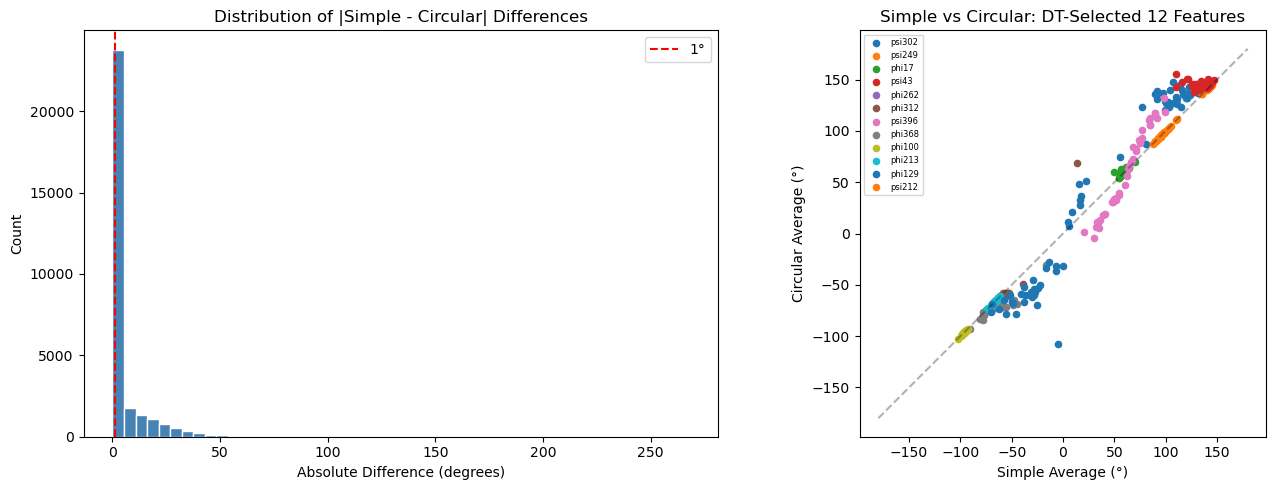

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean

original_12 = ['psi302', 'psi249', 'phi17', 'psi43', 'phi262', 'phi312',
               'psi396', 'phi368', 'phi100', 'phi213', 'phi129', 'psi212']

df_raw = pd.read_csv("pten.csv")
effect = {'no effect': 0, 'loss of function': 1}
df_raw['type'] = [effect[item] for item in df_raw['type']]

angle_cols = [c for c in df_raw.columns if c not in ['group', 'type']]

simple_avg = df_raw.groupby('group')[angle_cols].mean()

def circular_mean_deg(angles_deg):
    rad = np.deg2rad(angles_deg)
    return np.rad2deg(circmean(rad, high=np.pi, low=-np.pi))

circ_avg = df_raw.groupby('group')[angle_cols].apply(
    lambda grp: grp.apply(circular_mean_deg)
)

diff = (simple_avg - circ_avg).abs()

print("=" * 60)
print("Simple vs Circular Average Comparison (PTEN)")
print(f"Total features: {len(angle_cols)}")
print("=" * 60)

print(f"\nMax absolute difference across ALL features and groups: {diff.max().max():.4f}°")
print(f"Mean absolute difference: {diff.mean().mean():.4f}°")
print(f"\nFeatures with max diff > 1°: {(diff.max() > 1).sum()}")
print(f"Features with max diff > 5°: {(diff.max() > 5).sum()}")
print(f"Features with max diff > 10°: {(diff.max() > 10).sum()}")

print(f"\n--- DT-selected 12 features ---")
for feat in original_12:
    max_d = diff[feat].max()
    max_grp = diff[feat].idxmax()
    print(f"  {feat}: max diff = {max_d:.4f}° (at {max_grp})")
    if max_d > 1:
        print(f"    Simple: {simple_avg.loc[max_grp, feat]:.2f}°, "
              f"Circular: {circ_avg.loc[max_grp, feat]:.2f}°")

top_diff = diff.max().sort_values(ascending=False).head(20)
print(f"\nTop 20 features with largest simple vs circular difference:")
for feat, d in top_diff.items():
    grp = diff[feat].idxmax()
    in_orig = " ** (DT-selected)" if feat in original_12 else ""
    print(f"  {feat}: {d:.2f}° (at {grp}){in_orig}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(diff.values.flatten(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Absolute Difference (degrees)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of |Simple - Circular| Differences')
axes[0].axvline(x=1, color='red', linestyle='--', label='1°')
axes[0].legend()

for feat in original_12:
    s = simple_avg[feat].values
    c = circ_avg[feat].values
    axes[1].scatter(s, c, label=feat, s=20)
axes[1].plot([-180, 180], [-180, 180], 'k--', alpha=0.3)
axes[1].set_xlabel('Simple Average (°)')
axes[1].set_ylabel('Circular Average (°)')
axes[1].set_title('Simple vs Circular: DT-Selected 12 Features')
axes[1].legend(fontsize=6)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()


In [21]:
from collections import Counter
import builtins
import numpy as np
import pandas as pd
from scipy.stats import circmean
from sklearn.metrics import accuracy_score, matthews_corrcoef, confusion_matrix

original_12 = ['psi302', 'psi249', 'phi17', 'psi43', 'phi262', 'phi312',
               'psi396', 'phi368', 'phi100', 'phi213', 'phi129', 'psi212']

df_raw = pd.read_csv("pten.csv")
effect = {'no effect': 0, 'loss of function': 1}
df_raw['type'] = [effect[item] for item in df_raw['type']]

angle_cols = [c for c in df_raw.columns if c not in ['group', 'type']]
grouping = sorted(df_raw['group'].unique())

def circ_mean_deg(angles_deg):
    rad = np.deg2rad(angles_deg)
    return np.rad2deg(circmean(rad, high=np.pi, low=-np.pi))

def circular_distance(a, b):
    diff = np.abs(a - b)
    diff = np.minimum(diff, 360 - diff)
    return np.sqrt(np.sum(diff ** 2))

X_circ = df_raw.groupby('group')[angle_cols].apply(
    lambda grp: grp.apply(circ_mean_deg)
)
y_circ = df_raw.groupby('group')['type'].first()

K = 22

all_true, all_pred = [], []
fold_feats_22 = {}

for group in grouping:
    X_train = X_circ.loc[X_circ.index != group]
    X_test  = X_circ.loc[X_circ.index == group]
    y_train = y_circ.loc[X_train.index]

    c0_train = X_train[y_train == 0].apply(circ_mean_deg)
    c1_train = X_train[y_train == 1].apply(circ_mean_deg)

    feat_sep = pd.Series(
        {f: builtins.min(abs(c0_train[f] - c1_train[f]), 360 - abs(c0_train[f] - c1_train[f])) for f in angle_cols}
    ).sort_values(ascending=False)

    top_k = feat_sep.head(K).index.tolist()
    fold_feats_22[group] = top_k

    centroid_0 = c0_train[top_k].values
    centroid_1 = c1_train[top_k].values
    test_point = X_test[top_k].values[0]

    d0 = circular_distance(test_point, centroid_0)
    d1 = circular_distance(test_point, centroid_1)

    pred = 0 if d0 < d1 else 1
    true_label = int(y_circ.loc[group])

    all_true.append(true_label)
    all_pred.append(pred)

    status = "OK" if pred == true_label else "WRONG"
    print(f"  {group}: dist_noEffect={d0:.2f}, dist_LoF={d1:.2f}, "
          f"pred={pred}, true={true_label} [{status}]")

acc = accuracy_score(all_true, all_pred)
mcc = matthews_corrcoef(all_true, all_pred)
print(f"\nAccuracy: {acc:.3f} ({int(acc*len(grouping))}/{len(grouping)})")
print(f"MCC: {mcc:.3f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(all_true, all_pred)}")

print(f"\nWrong predictions at K={K}:")
for i, group in enumerate(grouping):
    if all_pred[i] != all_true[i]:
        label_true = "No Effect" if all_true[i] == 0 else "Loss of Function"
        label_pred = "No Effect" if all_pred[i] == 0 else "Loss of Function"
        print(f"  {group}: predicted {label_pred}, actually {label_true}")

# Feature frequency
all_sel = [f for feats in fold_feats_22.values() for f in feats]
feat_counts = Counter(all_sel)
print(f"\nAll {K} selected features at K={K} (frequency across folds):")
for f, c in feat_counts.most_common():
    in_dt = " ** (DT-selected)" if f in original_12 else ""
    print(f"  {f}: {c}/{len(grouping)} folds ({c/len(grouping)*100:.0f}%){in_dt}")

  A126D: dist_noEffect=176.81, dist_LoF=222.60, pred=0, true=1 [WRONG]
  A126G: dist_noEffect=295.81, dist_LoF=213.56, pred=1, true=1 [OK]
  A126P: dist_noEffect=229.30, dist_LoF=288.48, pred=0, true=0 [OK]
  A126S: dist_noEffect=206.62, dist_LoF=226.56, pred=0, true=0 [OK]
  A126V: dist_noEffect=189.51, dist_LoF=255.18, pred=0, true=0 [OK]
  C136F: dist_noEffect=262.31, dist_LoF=239.46, pred=1, true=1 [OK]
  D162H: dist_noEffect=178.50, dist_LoF=193.59, pred=0, true=0 [OK]
  D268E: dist_noEffect=220.63, dist_LoF=192.39, pred=1, true=0 [WRONG]
  E73K: dist_noEffect=215.26, dist_LoF=167.45, pred=1, true=1 [OK]
  F271S: dist_noEffect=167.84, dist_LoF=162.88, pred=1, true=1 [OK]
  F341V: dist_noEffect=228.80, dist_LoF=223.83, pred=1, true=1 [OK]
  G129D: dist_noEffect=227.26, dist_LoF=167.77, pred=1, true=1 [OK]
  G165E: dist_noEffect=243.39, dist_LoF=201.58, pred=1, true=1 [OK]
  I135K: dist_noEffect=203.92, dist_LoF=176.94, pred=1, true=1 [OK]
  I135T: dist_noEffect=240.75, dist_LoF=296